Exercícios Elisa

Imports:

In [2]:
%pip install pandas numpy matplotlib seaborn

  Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached numpy-2.4.2-cp314-cp314-win_amd64.whl (12.4 MB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-n

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

Exercício 1

In [6]:
dados_esp32 = {
    "Sensor_ID": [1, 2, 3, 4, 5, 6, 7, 8],
    "Temperatura_C": ["23.5", "falha_sinal", "21.0", "falha_sinal", "19.8", "falha_sinal", "25.3", "falha_sinal"]
}
df1 = pd.DataFrame(dados_esp32)

df1["Temperatura_C"] = pd.to_numeric(df1["Temperatura_C"], errors="coerce")

falhas = df1[df1["Temperatura_C"].isna()]
print("\nDataFrame completo:")
print(df1.to_string(index=False))
print(f"\nLinhas onde a conversão falhou ({len(falhas)} registros):")
print(falhas.to_string(index=False))


DataFrame completo:
 Sensor_ID  Temperatura_C
         1           23.5
         2            NaN
         3           21.0
         4            NaN
         5           19.8
         6            NaN
         7           25.3
         8            NaN

Linhas onde a conversão falhou (4 registros):
 Sensor_ID  Temperatura_C
         2            NaN
         4            NaN
         6            NaN
         8            NaN


___
Exercício 2

In [7]:
dados_compras = {
    "Compra_ID": [1, 2, 3, 4, 5, 6],
    "Data_Compra":  ["2024-01-10", "2024-02-05", "2024-03-01", "2024-03-15", "2024-04-01", "2024-04-20"],
    "Data_Entrega": ["2024-01-15", "2024-02-01", "2024-03-10", "2024-03-12", "2024-04-08", "2024-04-18"]
}
df2 = pd.DataFrame(dados_compras)

df2["Data_Compra"] = pd.to_datetime(df2["Data_Compra"])
df2["Data_Entrega"] = pd.to_datetime(df2["Data_Entrega"])

erros_logicos = df2[df2["Data_Entrega"] < df2["Data_Compra"]]
print("\nDataFrame completo:")
print(df2.to_string(index=False))
print(f"\nCompras com erro lógico (entrega antes do pedido) — {len(erros_logicos)} registro(s):")
print(erros_logicos.to_string(index=False) if not erros_logicos.empty else "Nenhum erro encontrado.")


DataFrame completo:
 Compra_ID Data_Compra Data_Entrega
         1  2024-01-10   2024-01-15
         2  2024-02-05   2024-02-01
         3  2024-03-01   2024-03-10
         4  2024-03-15   2024-03-12
         5  2024-04-01   2024-04-08
         6  2024-04-20   2024-04-18

Compras com erro lógico (entrega antes do pedido) — 3 registro(s):
 Compra_ID Data_Compra Data_Entrega
         2  2024-02-05   2024-02-01
         4  2024-03-15   2024-03-12
         6  2024-04-20   2024-04-18


___
Exercício 3

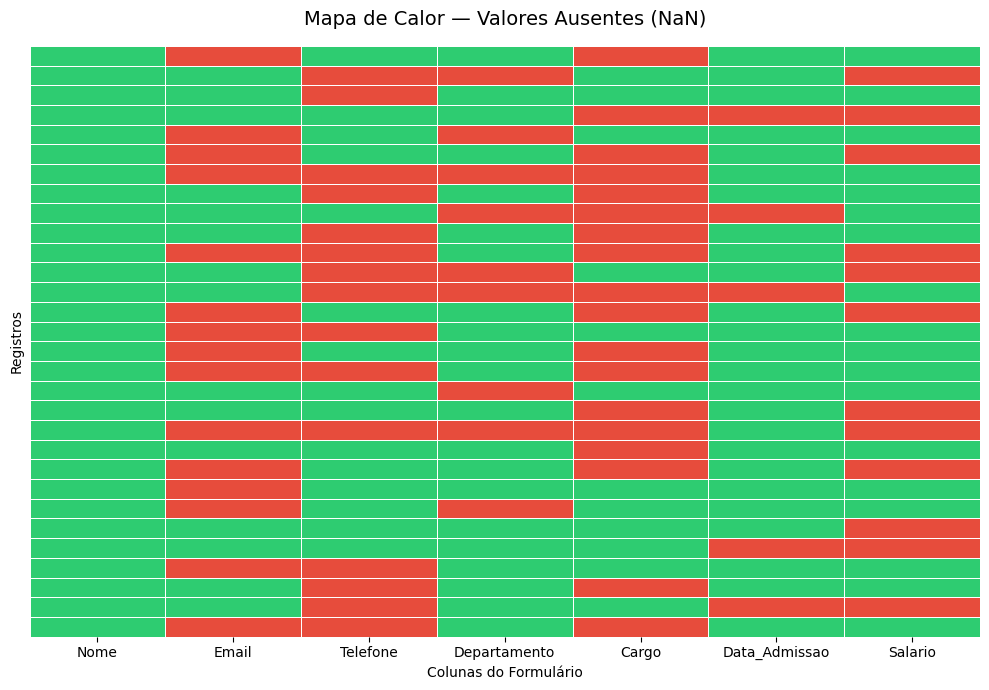

Total de NaN por coluna:
Nome              0
Email            15
Telefone         15
Departamento      9
Cargo            18
Data_Admissao     5
Salario          12


In [11]:
np.random.seed(42)
n = 30
df3 = pd.DataFrame({
    "Nome":           [f"Aluno_{i}" for i in range(n)],
    "Email":          [np.nan if np.random.rand() < 0.4 else f"email{i}@lab.com" for i in range(n)],
    "Telefone":       [np.nan if np.random.rand() < 0.5 else f"9{i:04d}-0000" for i in range(n)],
    "Departamento":   [np.nan if np.random.rand() < 0.3 else "TI" for _ in range(n)],
    "Cargo":          [np.nan if np.random.rand() < 0.6 else "Analista" for _ in range(n)],
    "Data_Admissao":  [np.nan if np.random.rand() < 0.2 else "2023-01-01" for _ in range(n)],
    "Salario":        [np.nan if np.random.rand() < 0.45 else round(np.random.uniform(2000, 8000), 2) for _ in range(n)],
})

ausentes = df3.isnull().astype(int)

plt.figure(figsize=(10, 7))
sns.heatmap(
    ausentes,
    cmap=["#2ecc71", "#e74c3c"],
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    yticklabels=False,
    xticklabels=df3.columns
)
plt.title("Mapa de Calor — Valores Ausentes (NaN)", fontsize=14, pad=15)
plt.xlabel("Colunas do Formulário")
plt.ylabel("Registros")
plt.tight_layout()
plt.show()
plt.close()
print(f"Total de NaN por coluna:\n{df3.isnull().sum().to_string()}")


___
Exercício 4

In [12]:
sistemas = (
    ["Ubuntu"] * 500 + ["Debian"] * 350 + ["Armbian"] * 120 +
    ["Ubuntuu"] * 10 + ["debain"] * 8 + ["UBUNTU"] * 6 +
    ["ArmbianOS"] * 4 + ["WindOwS"] * 2
)
np.random.shuffle(sistemas)
df4 = pd.DataFrame({"Sistema_Operacional": sistemas})

proporcoes = df4["Sistema_Operacional"].value_counts(normalize=True) * 100
print("\nProporção de cada categoria (%):")
print(proporcoes.round(2).to_string())

categorias_raras = proporcoes[proporcoes < 5].index
erros_digitacao = df4[df4["Sistema_Operacional"].isin(categorias_raras)]

print(f"\nCategorias que representam menos de 5% (prováveis erros de digitação):")
print(proporcoes[proporcoes < 5].round(2).to_string())
print(f"\nTotal de registros com categorias raras: {len(erros_digitacao)}")


Proporção de cada categoria (%):
Sistema_Operacional
Ubuntu       50.0
Debian       35.0
Armbian      12.0
Ubuntuu       1.0
debain        0.8
UBUNTU        0.6
ArmbianOS     0.4
WindOwS       0.2

Categorias que representam menos de 5% (prováveis erros de digitação):
Sistema_Operacional
Ubuntuu      1.0
debain       0.8
UBUNTU       0.6
ArmbianOS    0.4
WindOwS      0.2

Total de registros com categorias raras: 30


___
Exercício 5

In [17]:
df5 = pd.DataFrame({
    "Veiculo_ID": [1, 2, 3, 4, 5, 6],
    "Placa_Veiculo": ["ABC1234", "DEF567", "GHI9012", "JK34", "LMN5678X", "OPQ2345"]
})

df5["Comprimento"] = df5["Placa_Veiculo"].str.len()
placas_invalidas = df5[df5["Comprimento"] != 7]

print("\nDataFrame completo:")
print(df5.to_string(index=False))
print(f"\nPlacas com tamanho incorreto (≠ 7 caracteres) — {len(placas_invalidas)} registro(s):")
print(placas_invalidas.to_string(index=False))


DataFrame completo:
 Veiculo_ID Placa_Veiculo  Comprimento
          1       ABC1234            7
          2        DEF567            6
          3       GHI9012            7
          4          JK34            4
          5      LMN5678X            8
          6       OPQ2345            7

Placas com tamanho incorreto (≠ 7 caracteres) — 3 registro(s):
 Veiculo_ID Placa_Veiculo  Comprimento
          2        DEF567            6
          4          JK34            4
          5      LMN5678X            8


___
Exercício 6

In [18]:
ano_atual = datetime.now().year

df6 = pd.DataFrame({
    "Aluno_ID":             [1, 2, 3, 4, 5],
    "Ano_Nascimento":    [2000,   1998,    2005,    2001,    1995],
    "Idade_Declarada":   [24,     26,      17,      28,      30]
})

df6["Idade_Calculada"] = ano_atual - df6["Ano_Nascimento"]
df6["Diferenca"] = (df6["Idade_Calculada"] - df6["Idade_Declarada"]).abs()

inconsistentes = df6[df6["Diferenca"] > 1]   # tolerância de ±1 ano (aniversário ainda não ocorreu)

print("\nDataFrame completo:")
print(df6.to_string(index=False))
print(f"\nRegistros com idade inconsistente — {len(inconsistentes)} caso(s):")
print(inconsistentes.to_string(index=False))


DataFrame completo:
 Aluno_ID  Ano_Nascimento  Idade_Declarada  Idade_Calculada  Diferenca
        1            2000               24               26          2
        2            1998               26               28          2
        3            2005               17               21          4
        4            2001               28               25          3
        5            1995               30               31          1

Registros com idade inconsistente — 4 caso(s):
 Aluno_ID  Ano_Nascimento  Idade_Declarada  Idade_Calculada  Diferenca
        1            2000               24               26          2
        2            1998               26               28          2
        3            2005               17               21          4
        4            2001               28               25          3


___
Exercício 7

In [19]:
# Regra biológica: altura humana válida entre 0,5 m e 2,5 m
ALTURA_MIN = 0.5
ALTURA_MAX = 2.5

df7 = pd.DataFrame({
    "Paciente_ID":      [1, 2, 3, 4, 5, 6],
    "Altura_Metros": [1.75,   165.0,   1.82,    0.92,    190.0,    2.10]
})

alturas_invalidas = df7[~df7["Altura_Metros"].between(ALTURA_MIN, ALTURA_MAX)]

print(f"\nRegra aplicada: {ALTURA_MIN} m ≤ Altura ≤ {ALTURA_MAX} m")
print("\nDataFrame completo:")
print(df7.to_string(index=False))
print(f"\nPacientes com alturas impossíveis — {len(alturas_invalidas)} registro(s):")
print(alturas_invalidas.to_string(index=False))


Regra aplicada: 0.5 m ≤ Altura ≤ 2.5 m

DataFrame completo:
 Paciente_ID  Altura_Metros
           1           1.75
           2         165.00
           3           1.82
           4           0.92
           5         190.00
           6           2.10

Pacientes com alturas impossíveis — 2 registro(s):
 Paciente_ID  Altura_Metros
           2          165.0
           5          190.0


___
Exercício 8

In [20]:
# Restrições físicas: quantidade inteira, não negativa e abaixo de um limite máximo razoável
ESTOQUE_MAX = 100_000  # capacidade máxima do armazém

df8 = pd.DataFrame({
    "Componente_ID":        [1, 2, 3, 4, 5, 6, 7, 8],
    "Quantidade_Estoque": [500, -30, 1200, 99999.7, -1, 250, 110000, 0.5]
})

# Falhas: negativos, não-inteiros ou acima da capacidade máxima
falhas_estoque = df8[
    (df8["Quantidade_Estoque"] < 0) |
    (df8["Quantidade_Estoque"] != df8["Quantidade_Estoque"].apply(lambda x: int(x) if x == int(x) else x)) |
    (df8["Quantidade_Estoque"] > ESTOQUE_MAX)
]

print(f"\nRestrições: valor inteiro, ≥ 0 e ≤ {ESTOQUE_MAX:,}")
print("\nDataFrame completo:")
print(df8.to_string(index=False))
print(f"\nComponentes com falha de integridade — {len(falhas_estoque)} registro(s):")
print(falhas_estoque.to_string(index=False))


Restrições: valor inteiro, ≥ 0 e ≤ 100,000

DataFrame completo:
 Componente_ID  Quantidade_Estoque
             1               500.0
             2               -30.0
             3              1200.0
             4             99999.7
             5                -1.0
             6               250.0
             7            110000.0
             8                 0.5

Componentes com falha de integridade — 3 registro(s):
 Componente_ID  Quantidade_Estoque
             2               -30.0
             5                -1.0
             7            110000.0
